# Andaman Coral Reef — Exploratory Data Analysis

Downloads both Andaman datasets directly from **Google Drive** and performs a full EDA:
profiling, descriptive statistics, correlation analysis, and weekly time-series visualisation.

## 1. Install gdown

In [15]:
%pip install -q gdown

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import gdown
from pathlib import Path

data_dir = Path("../data/raw")
data_dir.mkdir(parents=True, exist_ok=True)

files = {
    "Andaman_WQ_20Year_Dataset.csv":    "1xGrP9394_Lg2NX7RWA_SYin6TfJhS7oI",
    "Andaman_WQ_Harmonized_20Year.csv": "1NuzkKS2m6Ty6NRpRbLWFab7rH2xpjtYv",
}

for filename, file_id in files.items():
    out_path = data_dir / filename
    if out_path.exists():
        print(f"Already exists: {filename}")
    else:
        print(f"Downloading {filename} ...")
        gdown.download(id=file_id, output=str(out_path), quiet=False)
        print(f"Saved -> {out_path}")

Downloading...
From: https://drive.google.com/uc?id=1xGrP9394_Lg2NX7RWA_SYin6TfJhS7oI
To: c:\Users\mudit\OneDrive\Desktop\Fourth Sem\Independent Study\data\raw\Andaman_WQ_20Year_Dataset.csv
100%|██████████| 4.58M/4.58M [00:00<00:00, 4.89MB/s]


Saved -> ..\data\raw\Andaman_WQ_20Year_Dataset.csv


Downloading...
From: https://drive.google.com/uc?id=1NuzkKS2m6Ty6NRpRbLWFab7rH2xpjtYv
To: c:\Users\mudit\OneDrive\Desktop\Fourth Sem\Independent Study\data\raw\Andaman_WQ_Harmonized_20Year.csv
100%|██████████| 4.95M/4.95M [00:00<00:00, 5.62MB/s]

Saved -> ..\data\raw\Andaman_WQ_Harmonized_20Year.csv


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

f_20y = data_dir / "Andaman_WQ_20Year_Dataset.csv"
f_h   = data_dir / "Andaman_WQ_Harmonized_20Year.csv"

df_20y = pd.read_csv(f_20y)
df_h   = pd.read_csv(f_h)

print("20-Year dataset    shape:", df_20y.shape)
print("Harmonized dataset shape:", df_h.shape)

20-Year dataset    shape: (4380, 8)
Harmonized dataset shape: (4380, 13)


In [18]:
print("=== 20-Year: first 5 rows ===")
df_20y.head()

=== 20-Year: first 5 rows ===


,system:index,chlor_a,label,sea_surface_temperature,total_nobs,total_precipitation,week_start,.geo
0,0_0,0.6342,Port_Blair,301.0044,7.9124,0.0000,2004-01-01,"{""type"":""Polygon"",""coordinates"":[[[92.74,11.70..."
1,0_1,0.9394,Havelock,300.9933,2.9900,0.0000,2004-01-01,"{""type"":""Polygon"",""coordinates"":[[[93.0,12.024..."
2,0_2,0.5327,Neil,300.9935,8.9808,0.0000,2004-01-01,"{""type"":""Polygon"",""coordinates"":[[[93.03,11.94..."
3,0_3,1.9189,Wandoor,301.0279,3.4772,0.0000,2004-01-01,"{""type"":""Polygon"",""coordinates"":[[[92.65000000..."
4,1_0,0.5996,Port_Blair,300.9265,5.9215,0.0000,2004-01-08,"{""type"":""Polygon"",""coordinates"":[[[92.74,11.70..."


In [19]:
print("=== Harmonized: first 5 rows ===")
df_h.head()

=== Harmonized: first 5 rows ===


,system:index,Rrs_443,Rrs_490,chlor_a,label,mslp,precip,sst,total_nobs,u_wind,v_wind,week_start,.geo
0,0_0,0.0050,0.0046,0.6342,Port_Blair,101340.6898,0.0000,301.0044,7.9124,-4.3883,-4.1795,2004-01-01,"{""type"":""Polygon"",""coordinates"":[[[92.74,11.70..."
1,0_1,0.0067,0.0071,0.9394,Havelock,101349.6016,0.0000,300.9933,2.9900,-3.9289,-4.3978,2004-01-01,"{""type"":""Polygon"",""coordinates"":[[[93.0,12.024..."
2,0_2,0.0051,0.0048,0.5327,Neil,101349.5593,0.0000,300.9935,8.9808,-3.9300,-4.3974,2004-01-01,"{""type"":""Polygon"",""coordinates"":[[[93.03,11.94..."
3,0_3,0.0051,0.0061,1.9189,Wandoor,101333.9496,0.0000,301.0279,3.4772,-4.5744,-4.1510,2004-01-01,"{""type"":""Polygon"",""coordinates"":[[[92.65000000..."
4,1_0,0.0055,0.0050,0.5996,Port_Blair,101286.0298,0.0000,300.9265,5.9215,-4.6583,-3.7373,2004-01-08,"{""type"":""Polygon"",""coordinates"":[[[92.74,11.70..."


In [20]:
def profile(df, name):
    rows = []
    for col in df.columns:
        rows.append({
            "column":    col,
            "dtype":     str(df[col].dtype),
            "non_null":  int(df[col].notna().sum()),
            "missing":   int(df[col].isna().sum()),
            "missing_%": round(df[col].isna().mean() * 100, 2),
            "n_unique":  int(df[col].nunique(dropna=True)),
        })
    out = pd.DataFrame(rows)
    print(f"\n==== {name}  ({df.shape[0]} rows x {df.shape[1]} cols) ====")
    return out.sort_values("missing_%", ascending=False)

profile(df_20y, "Andaman 20-Year")


==== Andaman 20-Year  (4380 rows x 8 cols) ====


,column,dtype,non_null,missing,missing_%,n_unique
1,chlor_a,float64,2779,1601,36.5500,2779
4,total_nobs,float64,2779,1601,36.5500,2605
2,label,str,4380,0,0.0000,4
0,system:index,str,4380,0,0.0000,4380
3,sea_surface_temperature,float64,4380,0,0.0000,4374
5,total_precipitation,float64,4380,0,0.0000,4359
6,week_start,str,4380,0,0.0000,1095
7,.geo,str,4380,0,0.0000,4


In [21]:
profile(df_h, "Andaman Harmonized")


==== Andaman Harmonized  (4380 rows x 13 cols) ====


,column,dtype,non_null,missing,missing_%,n_unique
1,Rrs_443,float64,2779,1601,36.5500,2779
3,chlor_a,float64,2779,1601,36.5500,2779
2,Rrs_490,float64,2779,1601,36.5500,2779
8,total_nobs,float64,2779,1601,36.5500,2605
0,system:index,str,4380,0,0.0000,4380
4,label,str,4380,0,0.0000,4
5,mslp,float64,4380,0,0.0000,4373
6,precip,float64,4380,0,0.0000,4359
7,sst,float64,4380,0,0.0000,4374
9,u_wind,float64,4380,0,0.0000,4380


In [22]:
print("=== 20-Year: Numeric Summary ===")
df_20y.describe().T

=== 20-Year: Numeric Summary ===


,count,mean,std,min,25%,50%,75%,max
chlor_a,2779.0000,0.5600,0.3137,0.1372,0.3515,0.4604,0.6713,2.5882
sea_surface_temperature,4380.0000,302.0840,0.8205,300.1355,301.5020,301.9732,302.4719,305.1367
total_nobs,2779.0000,4.6072,2.7490,0.1111,2.7274,4.2196,5.9931,20.5627
total_precipitation,4380.0000,0.0003,0.0003,-0.0000,0.0000,0.0002,0.0004,0.0017


In [23]:
print("=== Harmonized: Numeric Summary ===")
df_h.describe().T

=== Harmonized: Numeric Summary ===


,count,mean,std,min,25%,50%,75%,max
Rrs_443,2779.0000,0.0070,0.0020,0.0016,0.0058,0.0066,0.0076,0.0302
Rrs_490,2779.0000,0.0064,0.0021,0.0022,0.0050,0.0058,0.0071,0.0273
chlor_a,2779.0000,0.5600,0.3137,0.1372,0.3515,0.4604,0.6713,2.5882
mslp,4380.0000,100958.8051,208.3836,100363.7109,100802.2431,100947.8854,101120.8896,101536.8750
precip,4380.0000,0.0003,0.0003,-0.0000,0.0000,0.0002,0.0004,0.0017
sst,4380.0000,302.0840,0.8205,300.1355,301.5020,301.9732,302.4719,305.1367
total_nobs,2779.0000,4.6072,2.7490,0.1111,2.7274,4.2196,5.9931,20.5627
u_wind,4380.0000,0.7487,4.3972,-8.3080,-3.1473,-0.1590,4.9741,9.2955
v_wind,4380.0000,1.0016,3.4276,-5.7505,-1.9340,0.4664,4.1755,8.7087


In [24]:
KEYS = ["chl", "chlor", "turb", "sst", "temp", "wave", "kd", "atten", "light"]

def env_cols(df):
    return [c for c in df.columns if any(k in c.lower() for k in KEYS)]

env_20y = env_cols(df_20y)
env_h   = env_cols(df_h)

print("20-Year env columns:   ", env_20y)
print("Harmonized env columns:", env_h)

20-Year env columns:    ['chlor_a', 'sea_surface_temperature']
Harmonized env columns: ['chlor_a', 'sst']


In [25]:
DATE_HINTS = ["date", "datetime", "timestamp", "time", "week"]

def find_date_col(df):
    lmap = {c.lower(): c for c in df.columns}
    for hint in DATE_HINTS:
        for key, orig in lmap.items():
            if hint in key:
                return orig
    return None

date_20y = find_date_col(df_20y)
date_h   = find_date_col(df_h)
print("Date col in 20-Year:   ", date_20y)
print("Date col in Harmonized:", date_h)

if date_20y:
    df_20y[date_20y] = pd.to_datetime(df_20y[date_20y], errors="coerce")
    df_20y = df_20y.dropna(subset=[date_20y]).sort_values(date_20y).reset_index(drop=True)

if date_h:
    df_h[date_h] = pd.to_datetime(df_h[date_h], errors="coerce")
    df_h = df_h.dropna(subset=[date_h]).sort_values(date_h).reset_index(drop=True)

print("Date range (20-Year)   :", df_20y[date_20y].min() if date_20y else "N/A",
      "->", df_20y[date_20y].max() if date_20y else "N/A")
print("Date range (Harmonized):", df_h[date_h].min()   if date_h   else "N/A",
      "->", df_h[date_h].max()   if date_h   else "N/A")

Date col in 20-Year:    week_start
Date col in Harmonized: week_start
Date range (20-Year)   : 2004-01-01 00:00:00 -> 2024-12-19 00:00:00
Date range (Harmonized): 2004-01-01 00:00:00 -> 2024-12-19 00:00:00


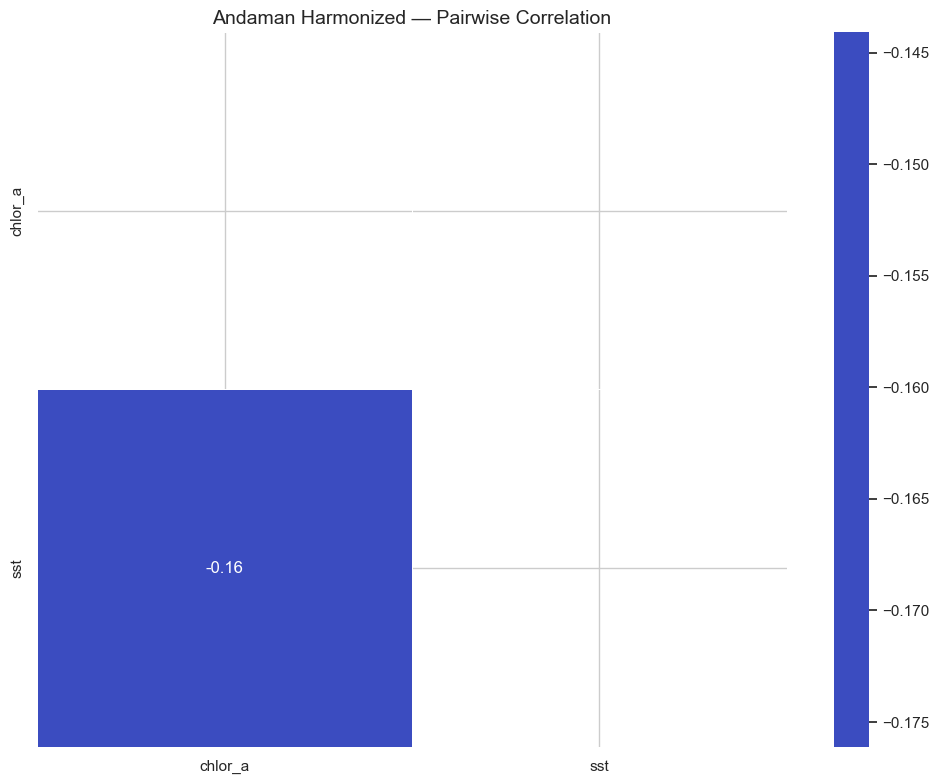

In [26]:
# Correlation heatmap (Harmonized dataset, env columns only)
num_h = df_h[[c for c in env_h if pd.api.types.is_numeric_dtype(df_h[c])]]

if len(num_h.columns) >= 2:
    corr = num_h.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0,
                annot=True, fmt=".2f", linewidths=0.4, ax=ax)
    ax.set_title("Andaman Harmonized — Pairwise Correlation", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric env columns found.")

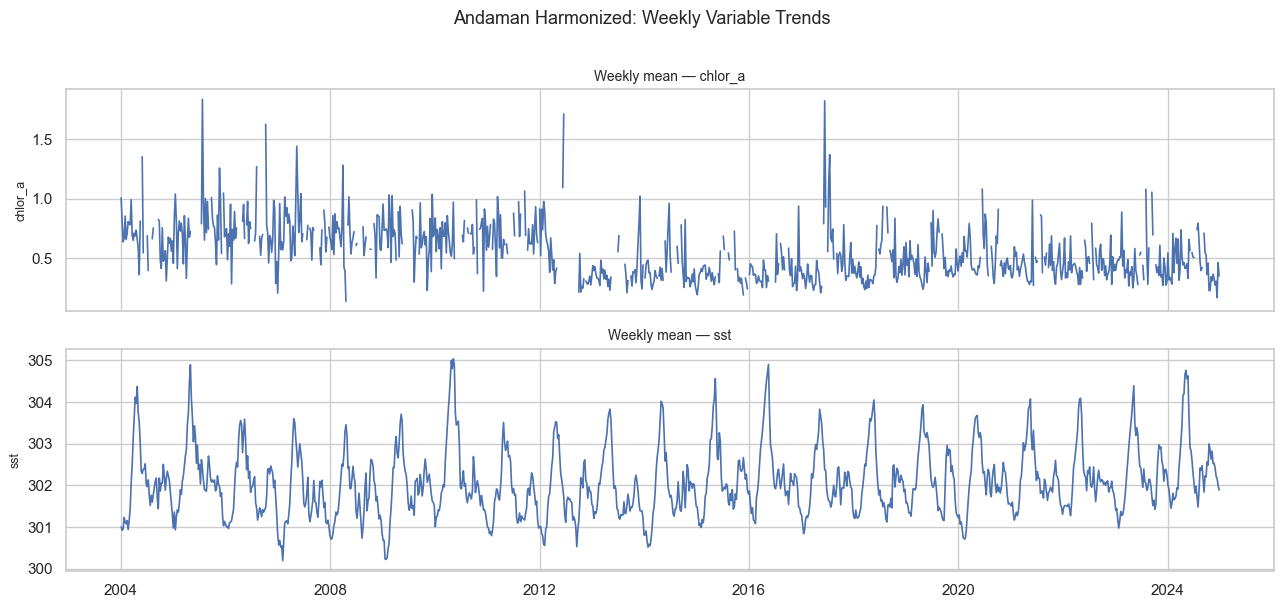

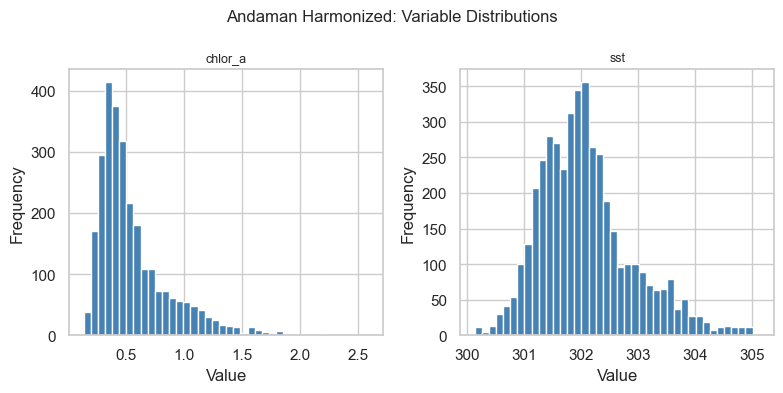

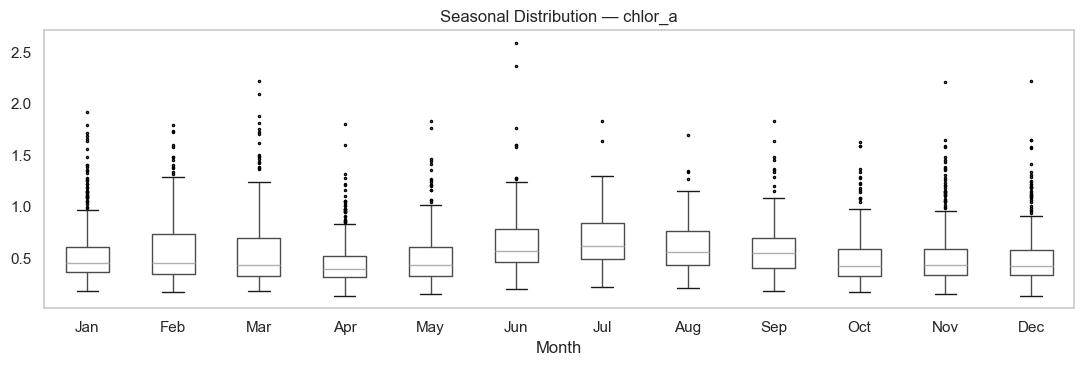

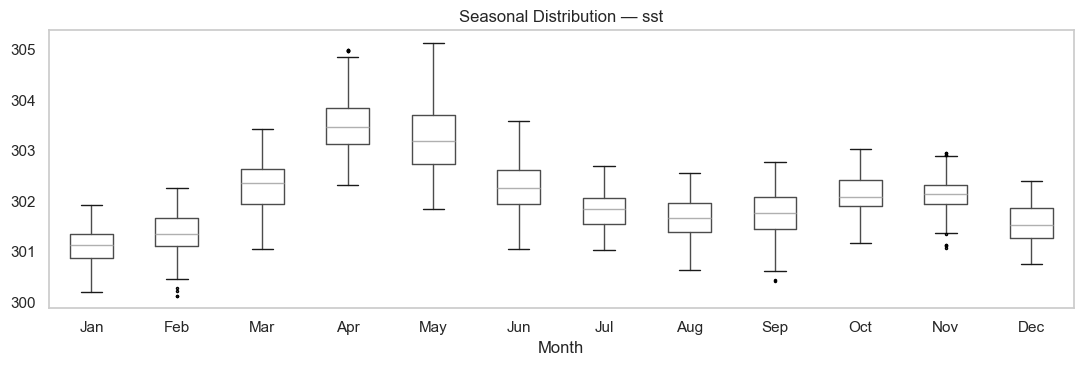

In [27]:
# Weekly resampled time-series trends
if date_h and len(env_h) > 0:
    plot_cols = [c for c in env_h if pd.api.types.is_numeric_dtype(df_h[c])][:6]
    weekly = (
        df_h.set_index(date_h)[plot_cols]
        .resample("W-MON").mean()
        .dropna(how="all")
    )
    n = len(plot_cols)
    fig, axes = plt.subplots(n, 1, figsize=(13, 3 * n), sharex=True)
    if n == 1:
        axes = [axes]
    for ax, col in zip(axes, plot_cols):
        ax.plot(weekly.index, weekly[col], linewidth=1.2)
        ax.set_ylabel(col, fontsize=9)
        ax.set_title(f"Weekly mean — {col}", fontsize=10)
    fig.suptitle("Andaman Harmonized: Weekly Variable Trends", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("No date column or env columns available for weekly plot.")

# ── Distribution histograms ──────────────────────────────────────────────────
num_env = [c for c in env_h if pd.api.types.is_numeric_dtype(df_h[c])][:6]
if num_env:
    n = len(num_env)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, col in zip(axes, num_env):
        df_h[col].dropna().plot.hist(ax=ax, bins=40, edgecolor="white", color="steelblue")
        ax.set_title(col, fontsize=9)
        ax.set_xlabel("Value")
    fig.suptitle("Andaman Harmonized: Variable Distributions", fontsize=12)
    plt.tight_layout()
    plt.show()

# ── Seasonal boxplots (by calendar month) ───────────────────────────────────
if date_h and num_env:
    df_h["month"] = df_h[date_h].dt.month
    month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"]
    for col in num_env[:4]:
        fig, ax = plt.subplots(figsize=(11, 4))
        df_h.boxplot(column=col, by="month", ax=ax, grid=False,
                     flierprops=dict(marker=".", markersize=3))
        ax.set_xticklabels([month_labels[m-1] for m in sorted(df_h["month"].dropna().astype(int).unique())])
        ax.set_title(f"Seasonal Distribution — {col}")
        ax.set_xlabel("Month")
        plt.suptitle("")
        plt.tight_layout()
        plt.show()

In [28]:
print("=== 20-Year columns ===")
print(df_20y.columns.tolist())
print("\n=== Harmonized columns ===")
print(df_h.columns.tolist())
print("\n=== 20-Year unique labels (reef sites) ===")
print(df_20y["label"].value_counts())
print("\n=== Date range: 20-Year    ===", df_20y["week_start"].min(), "->", df_20y["week_start"].max())
print("=== Date range: Harmonized ===", df_h["week_start"].min(), "->", df_h["week_start"].max())

=== 20-Year columns ===
['system:index', 'chlor_a', 'label', 'sea_surface_temperature', 'total_nobs', 'total_precipitation', 'week_start', '.geo']

=== Harmonized columns ===
['system:index', 'Rrs_443', 'Rrs_490', 'chlor_a', 'label', 'mslp', 'precip', 'sst', 'total_nobs', 'u_wind', 'v_wind', 'week_start', '.geo', 'month']

=== 20-Year unique labels (reef sites) ===
label
Port_Blair    1095
Havelock      1095
Neil          1095
Wandoor       1095
Name: count, dtype: int64

=== Date range: 20-Year    === 2004-01-01 00:00:00 -> 2024-12-19 00:00:00
=== Date range: Harmonized === 2004-01-01 00:00:00 -> 2024-12-19 00:00:00


print("=== 20-Year columns ===")
print(df_20y.columns.tolist())
print("\n=== Harmonized columns ===")
print(df_h.columns.tolist())
print("\n=== 20-Year unique labels (reef sites) ===")
print(df_20y["label"].value_counts())
print("\n=== Date range: 20-Year  ===", df_20y["week_start"].min(), "->", df_20y["week_start"].max())
print("=== Date range: Harmonized ===", df_h["week_start"].min(), "->", df_h["week_start"].max())